In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold

In [ ]:
# Load dataset
df = pd.read_csv("../../Dataset/quotes_customer_tier.csv")

C:\Users\nhail\AppData\Local\Temp\ipykernel_13328\562517546.py:2: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\nhail\Downloads\main_quotes_with_new_customer_tier.csv")


In [18]:
# Drop unnecessary columns
columns_to_drop = [
    'QuoteID', 'QuoteVersion', 'SalesPersonName', 'CustomerName', 
    'BranchName', 'Ship2State', 'Ship2City', 'ConvertedToOrderNumber', 'ConversionDate'
]
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns])


In [19]:
# Remove rows where 'QuoteStatus' is 'Revised'
df = df[df['QuoteStatus'] != 'Revised']


In [20]:
# Convert date columns to datetime
date_cols = ["QuoteDate", "ExpirationDate"]
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


In [21]:
# Create new date-related features
df["QuoteToExpireDays"] = (df["ExpirationDate"] - df["QuoteDate"]).dt.days


In [22]:
# Drop original datetime columns
df = df.drop(columns=date_cols)


In [23]:
# Fill missing values in numerical columns with the median
num_cols = df.select_dtypes(include=["number"]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


In [24]:
# Encode categorical variables
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le


In [25]:
# Define features (X) and target (y)
X = df.drop(columns=["QuoteStatus"])
y = df["QuoteStatus"]


In [26]:
# Apply Variance Threshold to remove low-variance features
selector = VarianceThreshold(threshold=0.01)
X_reduced = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]
X = pd.DataFrame(X_reduced, columns=selected_features)


In [27]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [28]:
# Initialize and train decision tree model
rf_model = DecisionTreeClassifier( max_depth=10, min_samples_split=10, min_samples_leaf=5, random_state=42)
rf_model.fit(X_train, y_train)


# Make predictions
y_pred = rf_model.predict(X_test)


In [29]:

# Predict on test set
y_pred = rf_model.predict(X_test)


In [30]:
# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)


In [31]:
# Print results
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:\n", report)


Accuracy: 0.8780
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.63      0.76    108745
           1       0.86      0.99      0.92    243571

    accuracy                           0.88    352316
   macro avg       0.91      0.81      0.84    352316
weighted avg       0.89      0.88      0.87    352316



In [32]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)


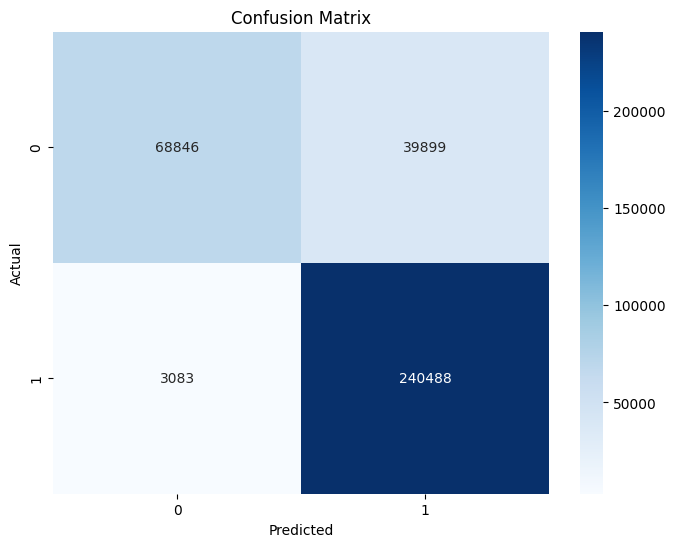

In [33]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


C:\Users\nhail\AppData\Local\Temp\ipykernel_13328\1873710493.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')


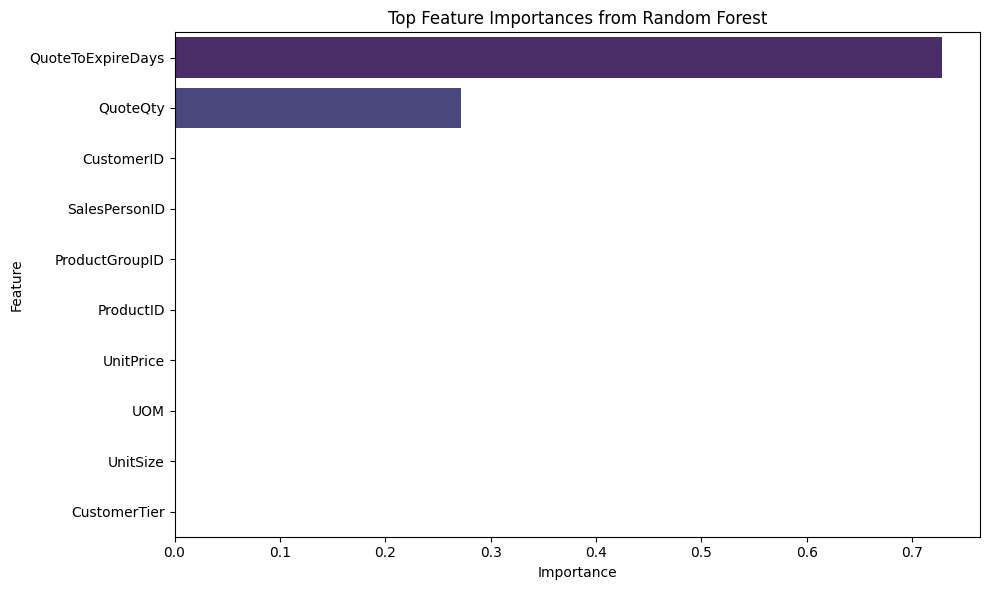

In [34]:
# Plot Feature Importances
importances = rf_model.feature_importances_
feature_names = X.columns

feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top Feature Importances from Random Forest')
plt.tight_layout()
plt.show()

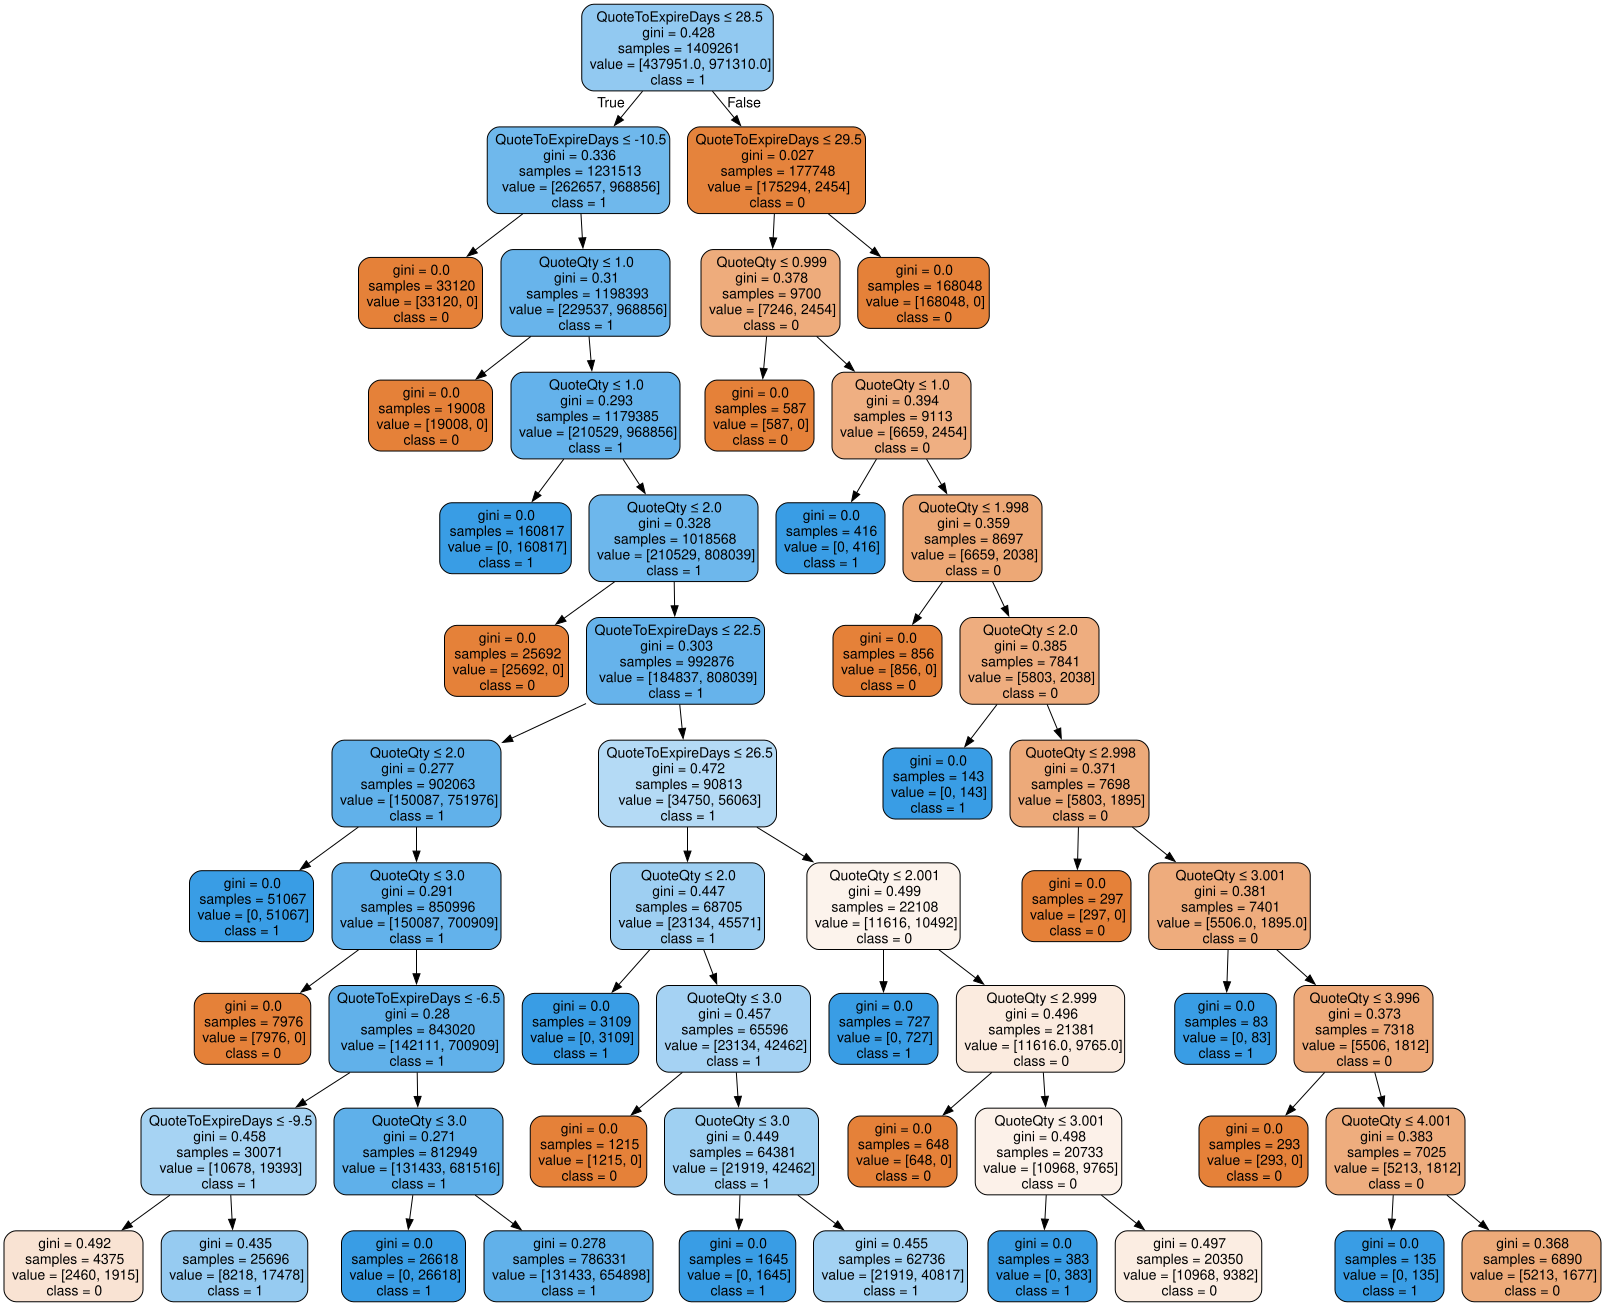

In [35]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    rf_model,
    out_file=None,
    feature_names=X.columns,
    class_names=[str(c) for c in rf_model.classes_],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("decision_tree")  # Saves the file (e.g., as PDF)
graph  # Displays the tree in a Jupyter Notebook